# 01. Single trajectory synthesis and score analysis

This notebook reproduces the **single-trajectory** part of the research workflow:
1. Parse and clean saved trajectories/scores from CSV exports.
2. Find the best observed trajectory in the dataset.
3. Rebuild a best control sequence for one initial condition with simulated annealing.
4. Recalculate and compare objective values using the paper/solver Bolza functional.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path.cwd().resolve()
if (base / 'src').exists():
    ROOT = base
elif (base / 'research' / 'src').exists():
    ROOT = base / 'research'
elif (base.parent / 'src').exists():
    ROOT = base.parent
else:
    raise RuntimeError('Cannot locate research/src directory from current working directory')

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))
from dynamics import CostConfig, build_trajectory_bundle, bolza_cost, load_training_samples, anneal

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


In [2]:
DATA_DIR = ROOT / 'src' / 'data'
samples = load_training_samples(DATA_DIR)
bundle = build_trajectory_bundle(samples)

print('Samples:', samples.shape)
print('Trajectories with scores:', len(bundle))
print('Steps range:', int(samples['step'].min()), '..', int(samples['step'].max()))
print(samples.head(3))


Samples: (16170, 13)
Trajectories with scores: 1078
Steps range: 1 .. 15
   trajectory_id  step        x1        x2        x3        x4        x5  \
0              1     1 -0.200000 -0.200000 -0.200000  0.000000  0.000000   
1              1     2 -0.510875 -0.275485 -0.125600 -1.665400 -0.404384   
2              1     3 -1.410614 -0.213993  0.095575 -3.154632  0.733806   

         x6        u1        u2        u3         u4      score  
0  0.000000  0.187504 -0.354690 -0.261799  11.806562  10.717483  
1  0.398569 -0.202423 -0.385951 -0.153431  11.954005  10.717483  
2  0.786299 -0.224996 -0.030610 -0.176636  10.474055  10.717483  


In [3]:
score_by_traj = samples[['trajectory_id', 'score']].drop_duplicates().sort_values('score')
best_tid = int(score_by_traj.iloc[0]['trajectory_id'])
worst_tid = int(score_by_traj.iloc[-1]['trajectory_id'])

print('Best observed trajectory id:', best_tid)
print('Best observed score:', float(score_by_traj.iloc[0]['score']))
print('Worst observed score:', float(score_by_traj.iloc[-1]['score']))
print('Top-10 observed trajectories:')
print(score_by_traj.head(10).to_string(index=False))


Best observed trajectory id: 1040
Best observed score: 5.628439447449216
Worst observed score: 180.69447547526855
Top-10 observed trajectories:
 trajectory_id    score
          1040 5.628439
           162 5.643882
           687 5.646878
          1000 5.657905
           842 5.658480
          1047 5.659009
           932 5.661025
           957 5.661259
           890 5.663216
           662 5.664261


In [4]:
cfg = CostConfig()
best_obs = bundle[best_tid]
X_obs = best_obs['X']
U_obs = best_obs['U']

calc_score = bolza_cost(X_obs[0], U_obs, cfg)
print('Best observed score from DB:', best_obs['score'])
print('Recomputed score (paper functional):', calc_score)
print('Absolute difference:', abs(best_obs['score'] - calc_score))


Best observed score from DB: 5.628439447449216
Recomputed score (paper functional): 5.628439447449216
Absolute difference: 0.0


In [8]:
np.random.seed(43)

# Simulated annealing for one selected initial state.
# We optimize controls directly and keep solver-compatible bounds.
def random_controls(n_steps: int) -> np.ndarray:
    low = np.array([-np.pi/12, -np.pi, -np.pi/12, 0.0])
    high = np.array([ np.pi/12,  np.pi,  np.pi/12, 12.0])
    return low + (high - low) * np.random.rand(n_steps, 4)

initial_state = X_obs[0].copy()
start_u = random_controls(15)

best_u_opt, best_j_opt, trace = anneal(initial_state, start_u, cfg, n_iter=300000)
print('Observed best score for selected initial state:', best_obs['score'])
print('Optimized score from annealing:', best_j_opt)
print('Improvement:', float(best_obs['score'] - best_j_opt))


Observed best score for selected initial state: 5.628439447449216
Optimized score from annealing: 5.6822410101047645
Improvement: -0.05380156265554881


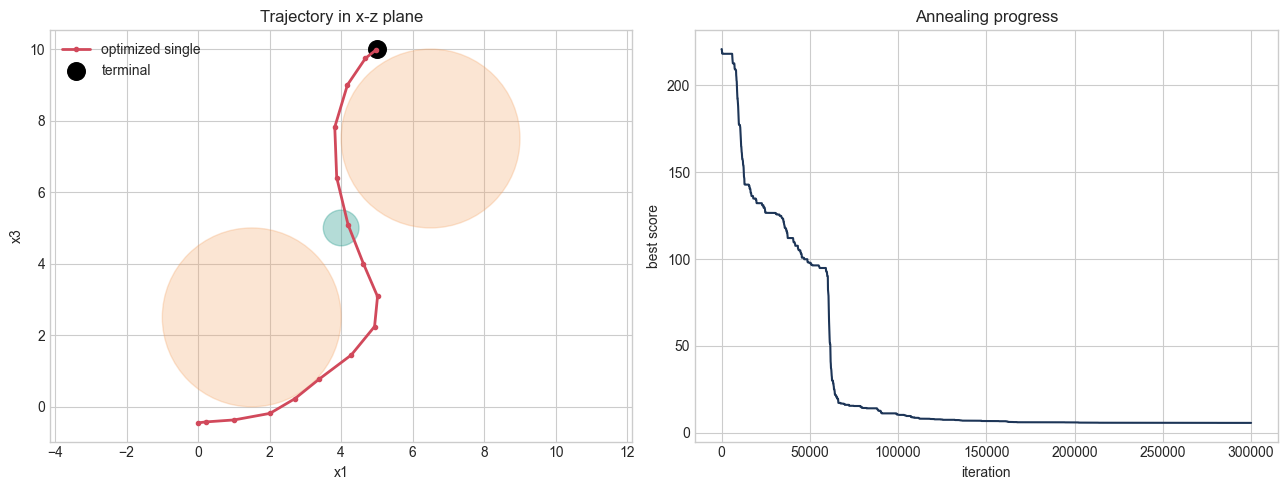

In [10]:
from dynamics import rollout

X_opt = rollout(initial_state, best_u_opt, cfg.dt)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# x-z geometry with obstacles and window
ax[0].plot(X_opt[:, 0], X_opt[:, 2], '-o', markersize=3, linewidth=2.0, color='#D1495B', label='optimized single')

for cyl in cfg.cylinders:
    c = plt.Circle((cyl.x, cyl.z), cyl.radius, color='#F4A261', alpha=0.28)
    ax[0].add_patch(c)
for wnd in cfg.windows:
    w = plt.Circle((wnd.x, wnd.z), wnd.radius, color='#2A9D8F', alpha=0.35)
    ax[0].add_patch(w)

ax[0].scatter([cfg.terminal_state[0]], [cfg.terminal_state[2]], marker='o', s=160, color='black', label='terminal')
ax[0].set_title('Trajectory in x-z plane')
ax[0].set_xlabel('x1')
ax[0].set_ylabel('x3')
ax[0].axis('equal')
ax[0].legend(loc='best')

ax[1].plot(np.arange(len(trace)) * 100, trace, color='#1D3557')
ax[1].set_title('Annealing progress')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('best score')

plt.tight_layout()
plt.show()


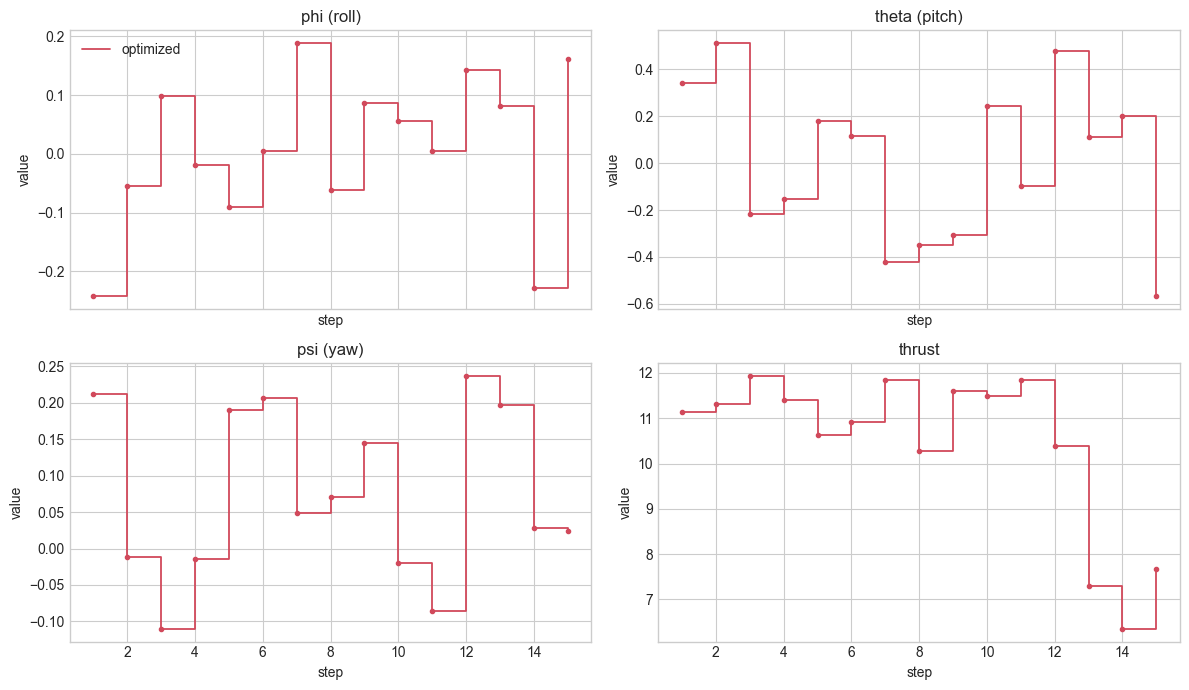

In [13]:
control_names = ['phi (roll)', 'theta (pitch)', 'psi (yaw)', 'thrust']
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()

steps = np.arange(1, U_obs.shape[0] + 1)

for j, ax in enumerate(axes):
    ax.step(
        steps,
        best_u_opt[:, j],
        where='post',          # значение держится до следующего шага
        color='#D1495B',
        linewidth=1.3,
        label='optimized',
    )
    ax.plot(steps, best_u_opt[:, j], 'o', color='#D1495B', markersize=3)  # опционально: показать узлы
    ax.set_title(control_names[j])
    ax.set_xlabel('step')
    ax.set_ylabel('value')

axes[0].legend()
plt.tight_layout()
plt.show()

### Result summary

- The notebook identifies the best stored single trajectory in the dataset.
- It recomputes the paper score from dynamics + penalties for consistency checks.
- It then runs trajectory-level simulated annealing from the same initial state and reports the improved score.
